# 🛢️ Simulador de Crisis Global: Petróleo y el Estrecho de Ormuz

El mercado global del **Petróleo Crudo** es el sistema venoso de la economía mundial. Según la **Agencia Internacional de Energía (AIE - IEA)** en su reporte de inicios de 2026, el mundo exige un consumo récord de **104.8 millones de barriles diarios (mb/d)** para mantener el transporte marítimo, aéreo y cadenas de producción funcionales.

Sin embargo, este suministro está expuesto a cuellos de botella geográficos (“Chokepoints”). El más crítico absoluto es el **Estrecho de Ormuz** (Golfo Pérsico). Según los registros de la **Administración de Información Energética de EE.UU. (EIA)**, por allí transitan en promedio **20.9 millones de barriles diarios**.

> **Dato Crítico:** Esto significa que *1 de cada 5 barriles (20%)* de petróleo consumido en el planeta, pasa por un canal de apenas 33 kilómetros de ancho controlado militarmente por Irán y Omán.

### Análisis de Riesgo Geopolítico (Estudio Estructural)
Si el conflicto entre Irán y EE.UU. u Occidente escala hasta hundir buques mercantes o minar la zona, nos enfrentamos a:
- **Inelasticidad de la Demanda:** Occidente no puede apagar su economía de un día para otro. Las matrices energéticas son rígidas a corto plazo y la demanda de diésel logístico se mantendrá alta.
- **Escasez Aguda (Shock de Oferta):** Retirar 20.9 mb/d del mercado no puede ser compensado por las reservas mundiales de la OCDE en el largo plazo, generando pánico adquisitivo y aumento de las pólizas de Seguros de Guerra (War Risk Premiums).
- **Efecto Dominó:** El petróleo caro genera **“Inflación Importada”** global. Sube el costo logístico de la agricultura mundial, lo que empuja a los Bancos Centrales a subir las tasas de interés, frenando en seco el crecimiento mundial e induciendo recesión global.

### El Motor de Simulación
A continuación, modelamos el mercado petrolero global con ecuaciones macroeconómicas en Python. Simularemos apagones logísticos en Medio Oriente para predecir si el barril rompería la barrera de los **$120 - $150 USD** en un escenario real de cierre total.

In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

import sys
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib as mpl
from ipywidgets import interact, FloatSlider


plt.style.use('default')
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['axes.facecolor'] = '#FFFFFF'
mpl.rcParams['figure.facecolor'] = '#FFFFFF'
mpl.rcParams['axes.grid'] = True
mpl.rcParams['grid.color'] = '#E0E0E0'
mpl.rcParams['grid.linestyle'] = '--'
mpl.rcParams['grid.alpha'] = 0.7
mpl.rcParams['text.color'] = '#333333'
mpl.rcParams['axes.labelcolor'] = '#333333'
mpl.rcParams['xtick.color'] = '#333333'
mpl.rcParams['ytick.color'] = '#333333'

COLOR_DEMANDA = "#1F77B4" # Azul Corporativo
COLOR_OFERTA = "#D62728"  # Rojo Alerta
COLOR_SHADE_PROD = "#2CA02C" # Verde Rentabilidad
COLOR_MARKER = "#FF7F0E" # Naranja Destacado

class MercadoLineal:
    """
    Clase para modelar un mercado básico de Oferta y Demanda Lineal.
    Usa el estándar de ejes: Precio (Y), Cantidad (X).

    Demanda: P = a - b*Q
    Oferta: P = c + d*Q
    """
    def __init__(self, a, b, c, d):
        self.a = a  # Intercepto Demanda (Precio Maximo dispuesto a pagar)
        self.b = b  # Pendiente Demanda
        self.c = c  # Intercepto Oferta (Precio Mínimo dispuesto a vender)
        self.d = d  # Pendiente Oferta

    def encontrar_equilibrio(self):
        """Calcula la Cantidad (Q) y Precio (P) de equilibrio algebraicamente."""
        if (self.b + self.d) == 0:
            return 0, 0

        q_eq = (self.a - self.c) / (self.b + self.d)
        p_eq = self.a - self.b * q_eq

        if q_eq < 0 or p_eq < 0:
            return 0, 0

        return q_eq, p_eq

    def calcular_excedentes(self):
        """
        Calcula el bienestar social:
        Excedente Consumidor (Área por encima del precio y debajo de la demanda)
        Excedente Productor (Área por debajo del precio y por encima de la oferta)
        """
        q_eq, p_eq = self.encontrar_equilibrio()
        if q_eq <= 0:
            return 0, 0

        exc_consumidor = 0.5 * q_eq * (self.a - p_eq)
        exc_productor = 0.5 * q_eq * (p_eq - self.c)

        return exc_consumidor, exc_productor

    def generar_coordenadas(self, q_max=None):
        """Genera arrays para plotear las rectas fácilmente en Matplotlib."""
        import numpy as np

        q_eq, _ = self.encontrar_equilibrio()
        if q_max is None:
            q_max = q_eq * 2 if q_eq > 0 else 100

        q_array = np.linspace(0, q_max, 100)

        p_demanda = self.a - self.b * q_array
        p_demanda = np.where(p_demanda < 0, 0, p_demanda) # No permitimos precios negativos visualmente

        p_oferta = self.c + self.d * q_array
        p_oferta = np.where(p_oferta < 0, 0, p_oferta)

        return q_array, p_demanda, p_oferta


### ⚖️ 1. Equilibrio Base (Pacífico)
Simulamos el mercado antes del inicio de hostilidades directas. La oferta OPEP+ y No-OPEP es constante, y la demanda global es estable (Q=100 Millones de barriles, Precio=$80 USD).

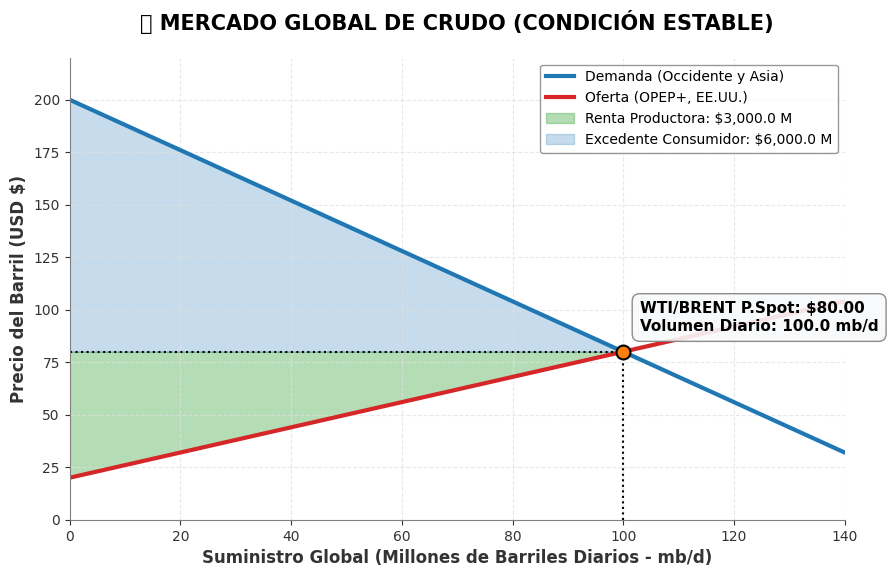

In [2]:
def graficar_mercado_petroleo(mercado, titulo="Terminal Global de Crudo"):
    q_eq, p_eq = mercado.encontrar_equilibrio()
    exc_cons, exc_prod = mercado.calcular_excedentes()
    q_array, p_demanda, p_oferta = mercado.generar_coordenadas(140)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    ax.plot(q_array, p_demanda, color=COLOR_DEMANDA, linewidth=3, label="Demanda (Occidente y Asia)")
    ax.plot(q_array, p_oferta, color=COLOR_OFERTA, linewidth=3, label="Oferta (OPEP+, EE.UU.)")
    
    if q_eq > 0:
        q_shade = np.linspace(0, q_eq, 100)
        p_of_shade = mercado.c + mercado.d * q_shade
        ax.fill_between(q_shade, p_of_shade, p_eq, color=COLOR_SHADE_PROD, alpha=0.35, label=f"Renta Productora: ${exc_prod:,.1f} M")
        
        p_dem_shade = mercado.a - mercado.b * q_shade
        ax.fill_between(q_shade, p_eq, p_dem_shade, color=COLOR_DEMANDA, alpha=0.25, label=f"Excedente Consumidor: ${exc_cons:,.1f} M")
        
        ax.vlines(x=q_eq, ymin=0, ymax=p_eq, colors='black', linestyles='dotted', linewidth=1.5)
        ax.hlines(y=p_eq, xmin=0, xmax=q_eq, colors='black', linestyles='dotted', linewidth=1.5)
        ax.plot(q_eq, p_eq, marker='o', color=COLOR_MARKER, markersize=10, markeredgecolor='black', markeredgewidth=1.5)
        
        ax.annotate(f"WTI/BRENT P.Spot: ${p_eq:.2f}\nVolumen Diario: {q_eq:.1f} mb/d",
                    xy=(q_eq, p_eq), xytext=(q_eq+3, p_eq+10),
                    fontsize=11, fontweight='bold', color='black',
                    bbox=dict(boxstyle="round,pad=0.5", fc="#F8F9FA", ec="gray", alpha=0.9))
        
    ax.set_xlim(0, 140)
    ax.set_ylim(0, max(mercado.a + 10, 220))
    ax.set_title(titulo, fontweight="bold", fontsize=15, color="black", pad=20, loc='center')
    
    ax.set_ylabel("Precio del Barril (USD $)", fontweight="bold", fontsize=12)
    ax.set_xlabel("Suministro Global (Millones de Barriles Diarios - mb/d)", fontweight="bold", fontsize=12)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('gray')
    ax.spines['bottom'].set_color('gray')
    
    ax.legend(loc='upper right', frameon=True, facecolor='#FFFFFF', edgecolor='gray', labelcolor='black')
    
    plt.show()

mercado_base = MercadoLineal(a=200, b=1.2, c=20, d=0.6)
graficar_mercado_petroleo(mercado_base, "🌐 MERCADO GLOBAL DE CRUDO (CONDICIÓN ESTABLE)")


### 🚨 2. Crisis Geo-Estratégica (SIMULACIÓN ORMUZ MLOps)

Te encuentras en la sala de operaciones macroeconómicas. Los reportes satelitales confirman ataques masivos en el Golfo Pérsico contra buques petroleros internacionales e instalaciones en Arabia Saudita y Qatar. Usa tu terminal predictiva para ver el impacto numérico:

- Mueve el **`Riesgo_Ormuz` (Sobrecosto Global de la Cadena de Suministro)**. Históricamente, sacar un barril cuesta en promedio $40~$50, pero si se cierra el estrecho más concurrido del mundo y flotas de la OTAN deben intervenir, los fletes y seguros empujarán el suelo de costo mínimo hacia los **$70 o $100 USD** por barril (un verdadero "Supply Shock").
- Simula un **`Pánico_Demanda`**. Los mercados especulan que no habrá combustible para el invierno. Las reservas de SPR (Strategic Petroleum Reserve) de EE.UU. se agotan, moviendo violentamente el techo que pagarán los países desarrollados por asegurarse el petróleo escaso hacia los $250 o $300.

>*Nota del Analista:* Observa cómo el volumen de "Distribución" que antes estaba saludable en más de 100 millones (mb/d), comenzará a desplomarse conforme el mundo entero pierde acceso a esos cruciales 20.9 millones de barriles que se quedaron atrapados en el Golfo Pérsico.

In [3]:
from IPython.display import display, HTML

@interact(
    Panico_Demanda=FloatSlider(min=150, max=300, step=5, value=200, description='Límite Pago Demanda ($):', continuous_update=True, style={'description_width': 'initial'}, layout={'width': '450px'}),
    Inelasticidad=FloatSlider(min=0.5, max=2.0, step=0.1, value=1.2, description='Rigidez Consumidor:', continuous_update=True, style={'description_width': 'initial'}, layout={'width': '450px'}),
    Riesgo_Ormuz=FloatSlider(min=20, max=120, step=5, value=20, description='[Shock de Guerra] Costo Base ($):', continuous_update=True, style={'description_width': 'initial'}, layout={'width': '450px'}),
    Dificultad_Of=FloatSlider(min=0.2, max=1.5, step=0.1, value=0.6, description='Dificultad Extracción:', continuous_update=True, style={'description_width': 'initial'}, layout={'width': '450px'})
)
def simulador_crisis(Panico_Demanda, Inelasticidad, Riesgo_Ormuz, Dificultad_Of):
    if Riesgo_Ormuz >= Panico_Demanda:
        display(HTML("<h3 style='color:red;'>🔴 APAGÓN GLOBAL: El crudo es incosteable. Comercio marítimo mundial detenido.</h3>"))
        return

    mercado_guerra = MercadoLineal(Panico_Demanda, Inelasticidad, Riesgo_Ormuz, Dificultad_Of)
    q, p = mercado_guerra.encontrar_equilibrio()

    if p > 100:
        alerta = f"<h4 style='color:#FF7B72;'>⚠️ PELIGRO INFLACIONARIO: Precio del Barril sobrepasó los $100. Riesgo crítico para EEUU/UE.</h4>"
    else:
        alerta = f"<h4 style='color:#3FB950;'>✅ ESTABILIDAD ENERGÉTICA MANTENIDA.</h4>"

    display(HTML(f"<b>[TERMINAL GEOPOLÍTICA]</b> Precio Proyectado: <b>${p:.2f} USD</b> | Déficit Global Suministro: <b>{-1 * (100 - q):.1f} mb/d</b><br>{alerta}"))

    graficar_mercado_petroleo(mercado_guerra, "🖥️ MONITOR DE IMPACTO GEOPOLÍTICO GLOBAL - ESTRECHO DE ORMUZ")



interactive(children=(FloatSlider(value=200.0, description='Límite Pago Demanda ($):', layout=Layout(width='45…

### 📹 Demostración del Modelo Interactivo
*(Esta es una animación del simulador en acción. Si descargas este cuaderno o lo abres en Binder, las barras superiores serán completamente operativas)*

![Simulador de Crisis Geopolítica](demo_simulador.gif)
